In [1]:
import os


os.environ["RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO"] = "0"
os.environ["RAY_DEDUP_LOGS"] = "1"

In [2]:
# %%
import matplotlib.pyplot as plt
import numpy as np
import ray
import pandas as pd


from mpl_toolkits.mplot3d import Axes3D

from starforge.blackholes.parameters_recover.parameters_recovery import (
    ParametersRecoveryRemote
)

from starforge.blackholes.parameters_recover.metrics import (
    nrmse_percent,
    smape_percent,
    stabilized_mape_percent,
)

from starforge.blackholes.accretionrate.blackholesaccretionrate import (
    ParameterAccretionRate
)

from starforge.blackholes.parameters_recover.utils import (
    add_noise_to_data,
    gaussian_sum_from_p,
    make_bounds_for_gaussians,
)

from starforge.blackholes.parameters_recover.schemes import (
    GridParameters
)

In [3]:
if ray.is_initialized() is False:
    ray.init(ignore_reinit_error=True)

2026-05-21 14:07:19,593	INFO worker.py:2004 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8267 


In [4]:
# ============================================================
# GRID
# ============================================================

mbh_steps = 25

grid_params = GridParameters(
    mbh_steps=mbh_steps,
    z_steps=mbh_steps * 100
)

ln_mbh_grid = np.linspace(
    grid_params.mbh_i,
    grid_params.mbh_f,
    grid_params.mbh_steps
)

In [5]:
# %%
# ============================================================
# BENCHMARK INITIAL CONDITION
# ============================================================

benchmark_params = np.array([
    3.3e-02,
    8.2e-03,
    5.4e-02,
    1.07e+01,
    1.29e+01,
    1.21e+01,
    6.93e-01,
    1.05e+00,
    7.47e-01
])

initial_condition = gaussian_sum_from_p(
    benchmark_params,
    ln_mbh_grid,
    n_gauss=3
)

In [6]:
# %%
# ============================================================
# PHYSICAL MODEL PARAMETERS
# ============================================================

accretion_params = ParameterAccretionRate(
    mbh_par=2e11,
    alpha_par=3e-1,
    tau_par=5e9,
    eta=0.1,
    t_q=1e9,
    b_1=0.1,
    b_2=0.1,
)

In [7]:
# ============================================================
# FORWARD SOLVER
# ============================================================

objective_function = ParametersRecoveryRemote.remote(
    grid_params=grid_params
)

In [8]:
# %%
# ============================================================
# REFERENCE FINAL BHMF
# ============================================================

reference_outputs = ray.get(
    objective_function.directly_problem.remote(
        initial_condition,
        accretion_params
    )
)

reference_final = reference_outputs.n_final

In [9]:
# ============================================================
# SYNTHETIC OBSERVATION
# ============================================================

noise_level = 0.01

target_data = add_noise_to_data(
    data=reference_final,
    mu=0.0,
    sigma=noise_level,
    rho=0.5,
    alpha=0.5,
    seed=52,
    noise_type='mixed'
)

In [10]:
# %%
# ============================================================
# OPTIMIZATION BOUNDS
# ============================================================

bounds = make_bounds_for_gaussians(
    x_min=6.0,
    x_max=15.0,
    preferred_center_index=2,
    preferred_center=12.0,
    preferred_center_radius=1.0,
    Amax=1e-1,
    sigma_min=0.01,
    sigma_max=5.0,
    sigma_max_preferred=1.0,
    K=3
)

bounds.extend([
    (0.5, 5.0),     # mbh_par
    (1.0, 10.0),    # tau_par
    (0.01, 0.6),    # alpha_par
    (0.01, 0.5),    # eta
    (0.5, 5.0),     # t_q
    (0.01, 0.5),    # b_1
    (0.01, 0.5),    # b_2
])

In [11]:
# %%
recovery = ParametersRecoveryRemote.remote(
    grid_params=grid_params
)

In [12]:
return_components = True

In [13]:
# %%
# ============================================================
# L-SURFACE COMPUTATION
# ============================================================

alpha_p_values = np.logspace(-4, 0, 5)
alpha_theta_values = np.logspace(-4, 0, 5)

results = []

for alpha_p in alpha_p_values:
    for alpha_theta in alpha_theta_values:

        print(
            f"Running optimization with "
            f"alpha_p={alpha_p:.2e}, "
            f"alpha_theta={alpha_theta:.2e}"
        )

        # ----------------------------------------------------
        # Optimization
        # ----------------------------------------------------

        best = ray.get(
            recovery.optimizer.remote(
                bounds=bounds,
                target_data=target_data,
                weight_p=alpha_p,
                weight_theta=alpha_theta,
                n_max=1,
                use_de=True,
                fast_mode=True,
            )
        )

        # ----------------------------------------------------
        # Diagnostics
        # ----------------------------------------------------

        diagnostics = ray.get(
            recovery.objective_function.remote(
                np.array(best.x),
                target_data,
                weight_p=alpha_p,
                weight_theta=alpha_theta,
                return_components=True
            )
        )

        results.append({
            "alpha_p": alpha_p,
            "alpha_theta": alpha_theta,
            "objective": diagnostics["objective"],
            "misfit": diagnostics["misfit"],
            "R_p": diagnostics["R_p"],
            "R_theta": diagnostics["R_theta"],
            "best_parameters": np.array(best.x),
        })

Running optimization with alpha_p=1.00e-04, alpha_theta=1.00e-04
(ParametersRecovery pid=635839) Starting optimization ...
(ParametersRecovery pid=635839) Objective value: 1.425727e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=635839) Objective value: 1.405378e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=635839) Objective value: 1.401135e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=635839) Objective value: 1.375083e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=635839) Objective value: 1.367915e+02 | Context: Minimum detected in annealing process


(ParametersRecovery pid=635839) /home/eduardo/Projects/starforge2/.venv/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
(ParametersRecovery pid=635839)   df = [f_eval - f0 for f_eval in f_evals]


(ParametersRecovery pid=635839) Objective value: 1.341282e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=635839) Objective value: 1.292251e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=635839) Objective value: 1.044261e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=635839) Objective value: 1.043186e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=635839) Objective value: 1.011398e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=635839) Objective value: 1.004027e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=635839) Objective value: 8.003415e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=635839) Objective value: 7.217618e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=635839) Objective value: 6.652289e+01 | Context: Minimum detected in annealing process
(

(ParametersRecovery pid=635839) /home/eduardo/Projects/starforge2/src/starforge/blackholes/parameters_recover/parameters_recovery.py:230: RuntimeWarning: invalid value encountered in log10
(ParametersRecovery pid=635839)   normalization_model = np.log10(params_array[-n:] + epsilon)


(ParametersRecovery pid=635839) Objective value: 9.259772e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=635839) Objective value: 8.853940e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=635839) Objective value: 7.900576e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=635839) Objective value: 7.872956e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=635839) Objective value: 7.537253e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=635839) Objective value: 7.534953e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=635839) Objective value: 7.401250e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=635839) Objective value: 7.395814e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=635839) Objective value: 5.873820e+01 | Context: Detection occurred in local search
(Par

In [59]:
# %%
# ============================================================
# SURFACE ARRAYS
# ============================================================

alpha_p_grid = np.array([r["alpha_p"] for r in results])
alpha_theta_grid = np.array([r["alpha_theta"] for r in results])

misfit_grid = np.array([r["misfit"] for r in results])

X = np.log10(alpha_p_grid)
Y = np.log10(alpha_theta_grid)
Z = np.log10(misfit_grid + 1e-15)

# Reshape to structured grid
X = X.reshape(len(alpha_p_values), len(alpha_theta_values))
Y = Y.reshape(len(alpha_p_values), len(alpha_theta_values))
Z = Z.reshape(len(alpha_p_values), len(alpha_theta_values))

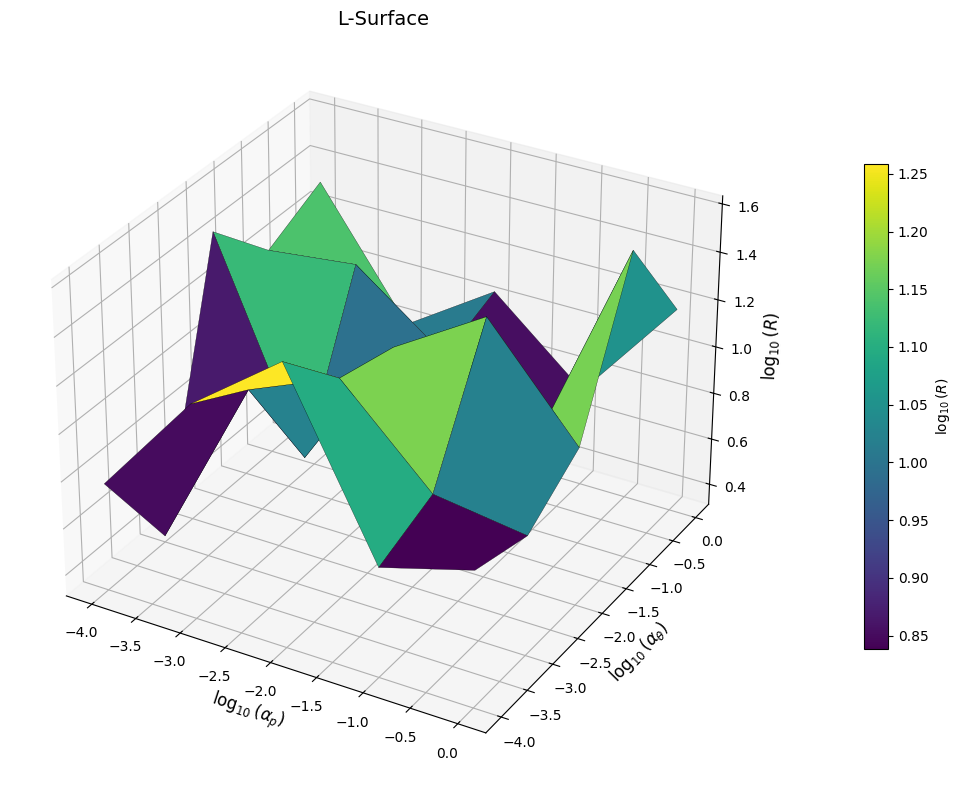

In [60]:
# %%
# ============================================================
# L-SURFACE PLOT
# ============================================================

fig = plt.figure(figsize=(11, 8))

ax = fig.add_subplot(111, projection="3d")

surface = ax.plot_surface(
    X,
    Y,
    Z,
    cmap="viridis",
    edgecolor="k",
    linewidth=0.2,
    antialiased=True
)

ax.set_xlabel(r"$\log_{10}(\alpha_p)$", fontsize=12)
ax.set_ylabel(r"$\log_{10}(\alpha_\theta)$", fontsize=12)
ax.set_zlabel(r"$\log_{10}(R)$", fontsize=12)

ax.set_title("L-Surface", fontsize=14)

fig.colorbar(
    surface,
    ax=ax,
    shrink=0.65,
    pad=0.1,
    label=r"$\log_{10}(R)$"
)

plt.tight_layout()
plt.show()

In [61]:
# %%

df = pd.DataFrame(results)

# ------------------------------------------------------------
# Log quantities
# ------------------------------------------------------------

epsilon = 1e-15

df["log_alpha_p"] = np.log10(df["alpha_p"] + epsilon)
df["log_alpha_theta"] = np.log10(df["alpha_theta"] + epsilon)

df["log_R"] = np.log10(df["misfit"] + epsilon)
df["log_R_p"] = np.log10(df["R_p"] + epsilon)
df["log_R_theta"] = np.log10(df["R_theta"] + epsilon)

df["log_J"] = np.log10(df["objective"] + epsilon)

In [62]:
df.to_csv("./results/monte_carlo_parameter_recover_results.csv", index=False)

In [63]:
df = pd.read_csv("./results/monte_carlo_parameter_recover_results.csv")

In [64]:
# %%
# ------------------------------------------------------------
# Pareto frontier
# ------------------------------------------------------------

costs = df[
    [
        "misfit",
        "R_p",
        "R_theta",
    ]
].values

n_points = costs.shape[0]

is_pareto = np.ones(n_points, dtype=bool)

for i in range(n_points):

    if not is_pareto[i]:
        continue

    for j in range(n_points):

        if i == j:
            continue

        dominates = (
            np.all(costs[j] <= costs[i]) and
            np.any(costs[j] < costs[i])
        )

        if dominates:

            is_pareto[i] = False
            break

df["pareto"] = is_pareto

print(
    f"Pareto-optimal points: "
    f"{df['pareto'].sum()} / {len(df)}"
)

Pareto-optimal points: 8 / 25


In [65]:
is_pareto

array([ True,  True, False, False, False, False,  True,  True, False,
        True, False,  True, False, False,  True, False, False, False,
        True, False, False, False, False, False, False])

In [66]:
# %%
# ------------------------------------------------------------
# Pareto subset
# ------------------------------------------------------------

pareto_df = (
    df[df["pareto"]]
    .copy()
    .reset_index(drop=False)
)

print(pareto_df[
    [
        "alpha_p",
        "alpha_theta",
        "misfit",
        "R_p",
        "R_theta",
        "objective",
    ]
])

   alpha_p  alpha_theta     misfit       R_p   R_theta  objective
0   0.0001       0.0001   5.868616  7.510038  5.993441   5.869966
1   0.0001       0.0010   2.174921  7.686529  5.336027   2.181026
2   0.0010       0.0010  12.080279  7.432258  6.459807  12.094171
3   0.0010       0.0100   3.947179  7.576836  6.285203   4.017608
4   0.0010       1.0000   6.305693  5.628519  6.705106  13.016428
5   0.0100       0.0010  17.378609  6.957014  6.517960  17.454697
6   0.0100       1.0000  11.170384  7.465999  5.350013  16.595057
7   0.1000       0.1000   4.858324  7.519701  5.072596   6.117554


In [67]:
pareto_df

,index,alpha_p,alpha_theta,objective,misfit,R_p,R_theta,best_parameters,log_alpha_p,log_alpha_theta,log_R,log_R_p,log_R_theta,log_J,pareto
0,0,0.0001,0.0001,5.869966,5.868616,7.510038,5.993441,[ 0.01506143 0.03295817 0.04370116 10.596389...,-4.0,-4.000000e+00,0.768536,0.875642,0.777676,0.768636,True
1,1,0.0001,0.0010,2.181026,2.174921,7.686529,5.336027,[1.63983120e-02 1.03714924e-02 6.25371451e-02 ...,-4.0,-3.000000e+00,0.337444,0.885730,0.727218,0.338661,True
2,6,0.0010,0.0010,12.094171,12.080279,7.432258,6.459807,[1.82099127e-03 2.02792714e-02 8.10428758e-02 ...,-3.0,-3.000000e+00,1.082077,0.871121,0.810220,1.082576,True
3,7,0.0010,0.0100,4.017608,3.947179,7.576836,6.285203,[ 0.01526763 0.02621899 0.05280127 10.525607...,-3.0,-2.000000e+00,0.596287,0.879488,0.798319,0.603968,True
4,9,0.0010,1.0000,13.016428,6.305693,5.628519,6.705106,[ 0. 0.06109176 0.02646206 9.187169...,-3.0,4.821637e-16,0.799733,0.750394,0.826406,1.114492,True
5,11,0.0100,0.0010,17.454697,17.378609,6.957014,6.517960,[8.03544995e-05 5.02970389e-02 4.25344563e-02 ...,-2.0,-3.000000e+00,1.240015,0.842423,0.814112,1.241912,True
6,14,0.0100,1.0000,16.595057,11.170384,7.465999,5.350013,[7.17836055e-03 3.26714118e-03 8.99778500e-02 ...,-2.0,4.821637e-16,1.048068,0.873088,0.728355,1.219979,True
7,18,0.1000,0.1000,6.117554,4.858324,7.519701,5.072596,[2.91171019e-02 6.46950211e-03 5.94512297e-02 ...,-1.0,-1.000000e+00,0.686486,0.876201,0.705230,0.786578,True


In [68]:
parameter_matrix = [[float(x) for x in i.replace("\n", "").replace("[", "").replace("]", "").split(" ") if x] for i in pareto_df["best_parameters"].values]

In [69]:
# %%
# ------------------------------------------------------------
# Stability metric in parameter space
# ------------------------------------------------------------



parameter_matrix = np.vstack(parameter_matrix)

stability = []

for i in range(len(pareto_df)):
    

    current = parameter_matrix[i]



    distances = np.linalg.norm(
        parameter_matrix - current,
        axis=1
    )

    distances[i] = np.inf

    nearest_distance = distances.min()

    stability.append(nearest_distance)

pareto_df["stability"] = stability

In [75]:
# %%
# ------------------------------------------------------------
# Automatic Pareto solution selection
# ------------------------------------------------------------

selection_df = pareto_df.copy()

# ------------------------------------------------------------
# Normalize objectives
# ------------------------------------------------------------

for col in ["misfit", "R_p", "R_theta"]:

    v = selection_df[col].values

    selection_df[f"{col}_norm"] = (
        (v - v.min()) /
        (v.max() - v.min() + 1e-15)
    )

# ------------------------------------------------------------
# Stability normalization
# higher stability = better
# ------------------------------------------------------------

s = selection_df["stability"].values

selection_df["stability_norm"] = (
    (s - s.min()) /
    (s.max() - s.min() + 1e-15)
)

# ------------------------------------------------------------
# Global score
# lower is better
# ------------------------------------------------------------

selection_df["score"] = (
    selection_df["misfit_norm"]
    +
    selection_df["R_p_norm"]
    +
    selection_df["R_theta_norm"]
    -
    selection_df["stability_norm"]
)

# ------------------------------------------------------------
# Best Pareto solution
# ------------------------------------------------------------

best_idx = selection_df["score"].idxmin()

best_row = selection_df.loc[best_idx]

print("\nAutomatically selected solution:\n")

print(best_row[
    [
        "alpha_p",
        "alpha_theta",
        "misfit",
        "R_p",
        "R_theta",
        "objective",
        "stability",
        "score",
    ]
])


Automatically selected solution:

alpha_p             0.1
alpha_theta         0.1
misfit         4.858324
R_p            7.519701
R_theta        5.072596
objective      6.117554
stability      2.821113
score          0.322174
Name: 7, dtype: object


[0.0291171019,
 0.00646950211,
 0.0594512297,
 10.4593625,
 13.0630241,
 11.7799589,
 0.658713863,
 1.08331395,
 0.780404078,
 2.48965572,
 5.79442993,
 0.327970224,
 0.0321599233,
 0.515432769,
 0.418108368,
 0.462418176]

In [82]:
# %%
# ------------------------------------------------------------
# Recover selected parameters
# ------------------------------------------------------------

selected_parameters = [float(x) for x in best_row["best_parameters"].replace("\n", "").replace("[", "").replace("]", "").split(" ") if x] 

print("\nRecovered parameters:\n")

for i, value in enumerate(selected_parameters):

    print(f"p[{i}] = {value}")


Recovered parameters:

p[0] = 0.0291171019
p[1] = 0.00646950211
p[2] = 0.0594512297
p[3] = 10.4593625
p[4] = 13.0630241
p[5] = 11.7799589
p[6] = 0.658713863
p[7] = 1.08331395
p[8] = 0.780404078
p[9] = 2.48965572
p[10] = 5.79442993
p[11] = 0.327970224
p[12] = 0.0321599233
p[13] = 0.515432769
p[14] = 0.418108368
p[15] = 0.462418176


In [84]:
# %%
# ------------------------------------------------------------
# Neighbor analysis around selected solution
# ------------------------------------------------------------

pareto_df["distance"] = np.sqrt(
    (
        pareto_df["log_alpha_p"] -
        best_row["log_alpha_p"]
    )**2
    +
    (
        pareto_df["log_alpha_theta"] -
        best_row["log_alpha_theta"]
    )**2
)

neighbors = (
    pareto_df
    .sort_values("distance")
    .head(7)
    .copy()
)

neighbors = neighbors.sort_values(
    by=[
        "log_alpha_p",
        "log_alpha_theta",
    ]
)

print(neighbors[
    [
        "log_alpha_p",
        "log_alpha_theta",
        "log_R",
        "log_R_p",
        "log_R_theta",
        "log_J",
        "stability",
    ]
])

   log_alpha_p  log_alpha_theta     log_R   log_R_p  log_R_theta     log_J  \
1         -4.0    -3.000000e+00  0.337444  0.885730     0.727218  0.338661   
2         -3.0    -3.000000e+00  1.082077  0.871121     0.810220  1.082576   
3         -3.0    -2.000000e+00  0.596287  0.879488     0.798319  0.603968   
4         -3.0     4.821637e-16  0.799733  0.750394     0.826406  1.114492   
5         -2.0    -3.000000e+00  1.240015  0.842423     0.814112  1.241912   
6         -2.0     4.821637e-16  1.048068  0.873088     0.728355  1.219979   
7         -1.0    -1.000000e+00  0.686486  0.876201     0.705230  0.786578   

   stability  
1   1.337726  
2   3.256080  
3   2.434605  
4   2.434605  
5   1.581977  
6   1.337726  
7   2.821113  


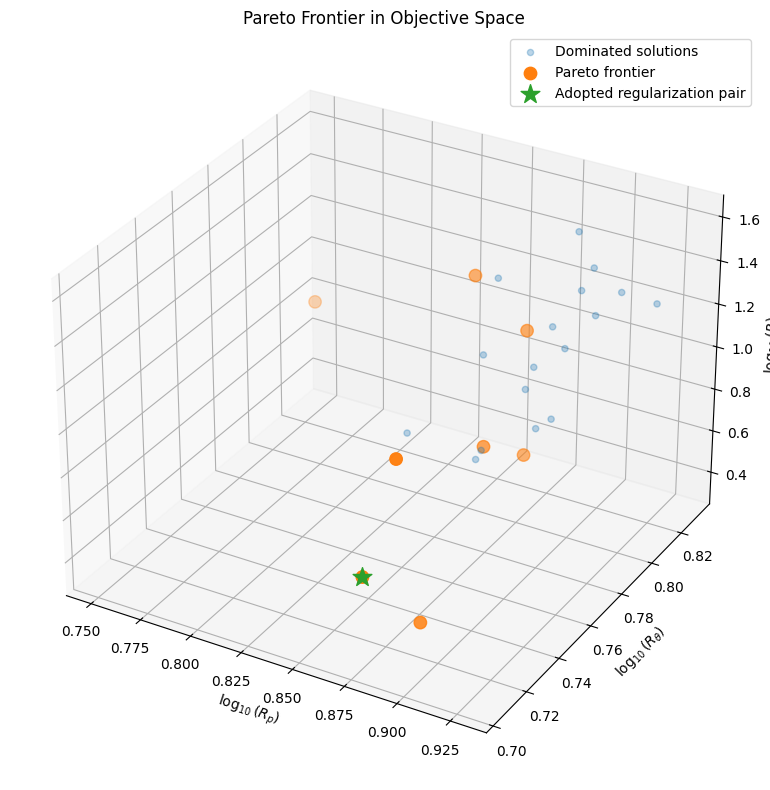

In [85]:
# %%
# ------------------------------------------------------------
# 3D Pareto visualization
# ------------------------------------------------------------

fig = plt.figure(figsize=(11, 8))

ax = fig.add_subplot(111, projection="3d")

non_pareto = df[~df["pareto"]]

ax.scatter(
    non_pareto["log_R_p"],
    non_pareto["log_R_theta"],
    non_pareto["log_R"],
    alpha=0.3,
    label="Dominated solutions"
)

ax.scatter(
    pareto_df["log_R_p"],
    pareto_df["log_R_theta"],
    pareto_df["log_R"],
    s=80,
    label="Pareto frontier"
)

ax.scatter(
    best_row["log_R_p"],
    best_row["log_R_theta"],
    best_row["log_R"],
    s=200,
    marker="*",
    label="Adopted regularization pair"
)

ax.set_xlabel(r"$\log_{10}(R_p)$")
ax.set_ylabel(r"$\log_{10}(R_\theta)$")
ax.set_zlabel(r"$\log_{10}(R)$")

ax.set_title(
    "Pareto Frontier in Objective Space"
)

ax.legend()

plt.tight_layout()
plt.show()

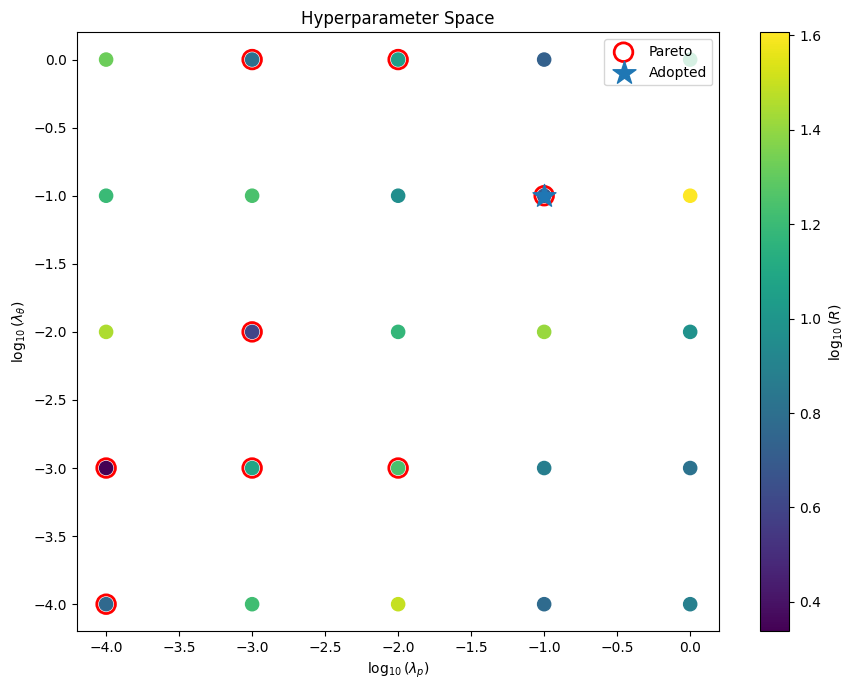

In [86]:
# %%
# ------------------------------------------------------------
# 2D hyperparameter map
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(9, 7)
)

scatter = ax.scatter(
    df["log_alpha_p"],
    df["log_alpha_theta"],
    c=df["log_R"],
    s=90,
    cmap="viridis",
)

ax.scatter(
    pareto_df["log_alpha_p"],
    pareto_df["log_alpha_theta"],
    s=180,
    facecolors="none",
    edgecolors="red",
    linewidths=2,
    label="Pareto"
)

ax.scatter(
    best_row["log_alpha_p"],
    best_row["log_alpha_theta"],
    s=300,
    marker="*",
    label="Adopted"
)

ax.set_xlabel(
    r"$\log_{10}(\lambda_p)$"
)

ax.set_ylabel(
    r"$\log_{10}(\lambda_\theta)$"
)

ax.set_title(
    "Hyperparameter Space"
)

cbar = plt.colorbar(scatter)

cbar.set_label(
    r"$\log_{10}(R)$"
)

ax.legend()

plt.tight_layout()
plt.show()

In [88]:
# %%
# ------------------------------------------------------------
# Generate LaTeX table
# ------------------------------------------------------------

columns = [
    "log_alpha_p",
    "log_alpha_theta",
    "log_R",
    "log_R_theta",
    "log_R_p",
    "log_J",
    "stability",
]

latex_rows = []

selected_log_alpha_p = np.log10(selected_lambda_p)
selected_log_alpha_theta = np.log10(selected_lambda_theta)

for _, row in neighbors.iterrows():

    is_selected = (
        np.isclose(
            row["log_alpha_p"],
            selected_log_alpha_p
        )
        and
        np.isclose(
            row["log_alpha_theta"],
            selected_log_alpha_theta
        )
    )

    if is_selected:

        values = [
            rf"\textbf{{{row[col]:.6f}}}"
            for col in columns
        ]

    else:

        values = [
            f"{row[col]:.6f}"
            for col in columns
        ]

    line = " & ".join(values) + r" \\"

    latex_rows.append(line)

latex_table = rf"""
\begin{{table}}
\centering

\caption{{
Representative Pareto-optimal solutions around the adopted
regularization regime.
The column ``Local Sensitivity'' corresponds to the minimum
Euclidean distance between neighboring Pareto-optimal parameter
vectors in the reconstruction space.
Smaller values indicate locally stable reconstructions under
perturbations of the regularization hyperparameters.
}}

\label{{tab:pareto_optimum}}

\resizebox{{\linewidth}}{{!}}{{
\begin{{tabular}}{{ccccccc}}
\hline

$\log \lambda_{{p}}$
&
$\log \lambda_{{\theta}}$
&
$\log R$
&
$\log R_{{\theta}}$
&
$\log R_{{p}}$
&
$\log J$
&
Stability
\\

\hline

{chr(10).join(latex_rows)}

\hline
\end{{tabular}}
}}

\end{{table}}
"""

print(latex_table)


\begin{table}
\centering

\caption{
Representative Pareto-optimal solutions around the adopted
regularization regime.
The column ``Local Sensitivity'' corresponds to the minimum
Euclidean distance between neighboring Pareto-optimal parameter
vectors in the reconstruction space.
Smaller values indicate locally stable reconstructions under
perturbations of the regularization hyperparameters.
}

\label{tab:pareto_optimum}

\resizebox{\linewidth}{!}{
\begin{tabular}{ccccccc}
\hline

$\log \lambda_{p}$
&
$\log \lambda_{\theta}$
&
$\log R$
&
$\log R_{\theta}$
&
$\log R_{p}$
&
$\log J$
&
Stability
\\

\hline

-4.000000 & -3.000000 & 0.337444 & 0.727218 & 0.885730 & 0.338661 & 1.337726 \\
-3.000000 & -3.000000 & 1.082077 & 0.810220 & 0.871121 & 1.082576 & 3.256080 \\
-3.000000 & -2.000000 & 0.596287 & 0.798319 & 0.879488 & 0.603968 & 2.434605 \\
-3.000000 & 0.000000 & 0.799733 & 0.826406 & 0.750394 & 1.114492 & 2.434605 \\
-2.000000 & -3.000000 & 1.240015 & 0.814112 & 0.842423 & 1.241912 & 1.

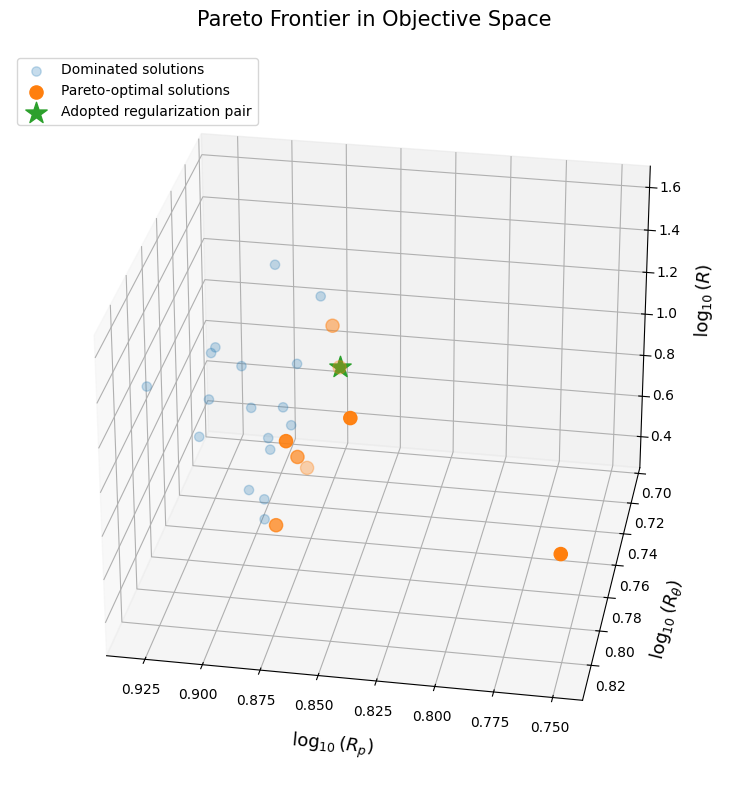

In [90]:
# %%
# ------------------------------------------------------------
# Pareto frontier in objective space
# ------------------------------------------------------------

fig = plt.figure(figsize=(20, 8))

ax = fig.add_subplot(111, projection="3d")

# ------------------------------------------------------------
# Dominated solutions
# ------------------------------------------------------------

non_pareto = df[~df["pareto"]]

ax.scatter(
    non_pareto["log_R_p"],
    non_pareto["log_R_theta"],
    non_pareto["log_R"],
    s=45,
    alpha=0.25,
    label="Dominated solutions"
)

# ------------------------------------------------------------
# Pareto-optimal solutions
# ------------------------------------------------------------

ax.scatter(
    pareto_df["log_R_p"],
    pareto_df["log_R_theta"],
    pareto_df["log_R"],
    s=90,
    label="Pareto-optimal solutions"
)

# ------------------------------------------------------------
# Adopted regularization pair
# ------------------------------------------------------------

ax.scatter(
    best_row["log_R_p"],
    best_row["log_R_theta"],
    best_row["log_R"],
    s=260,
    marker="*",
    label="Adopted regularization pair"
)

# ------------------------------------------------------------
# Axis labels
# ------------------------------------------------------------

ax.set_xlabel(
    r"$\log_{10}(R_{p})$",
    fontsize=13,
    labelpad=12
)

ax.set_ylabel(
    r"$\log_{10}(R_{\theta})$",
    fontsize=13,
    labelpad=12
)

ax.set_zlabel(
    r"$\log_{10}(R)$",
    fontsize=13,
    labelpad=12
)

# ------------------------------------------------------------
# Title
# ------------------------------------------------------------

ax.set_title(
    "Pareto Frontier in Objective Space",
    fontsize=15,
    pad=18
)

# ------------------------------------------------------------
# View angle
# ------------------------------------------------------------

ax.view_init(
    elev=28,
    azim=100
)

# ------------------------------------------------------------
# Grid and legend
# ------------------------------------------------------------

ax.grid(True)

ax.legend(
    loc="upper left",
    fontsize=10
)

plt.tight_layout()

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

plt.savefig(
    "./images/pareto_surface.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()